# Plotting

In [1]:
import mammos_units as u

import mammos_entity as me
import mammos_entity.pyplot as plt

In [2]:
ec = me.EntityCollection(
    T=me.T([200, 300, 400]),
    M=me.M([300, 200, 100], "kA/m"),
    M2=me.M([0.4, 0.35, 0.3], "MA/m"),
    B=me.B([250, 250, 250], "mT"),
    M3=[200, 400, 200] * u.kA / u.m,
)
ec

EntityCollection(
    T=Entity(ontology_label='ThermodynamicTemperature', value=array([200., 300., 400.]), unit='K'),
    M=Entity(ontology_label='Magnetization', value=array([300., 200., 100.]), unit='kA / m'),
    M2=Entity(ontology_label='Magnetization', value=array([0.4 , 0.35, 0.3 ]), unit='MA / m'),
    B=Entity(ontology_label='MagneticFluxDensity', value=array([250., 250., 250.]), unit='mT'),
    M3=<Quantity [200., 400., 200.] kA / m>,
)

## Same entity, different unit

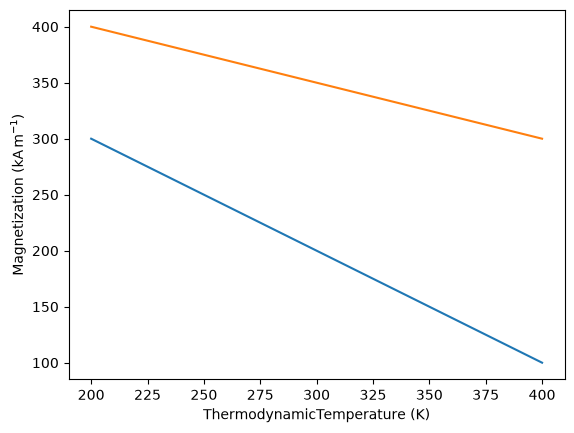

In [3]:
plt.plot(ec.T, ec.M)
plt.plot(ec.T, ec.M2)

## Reversing order

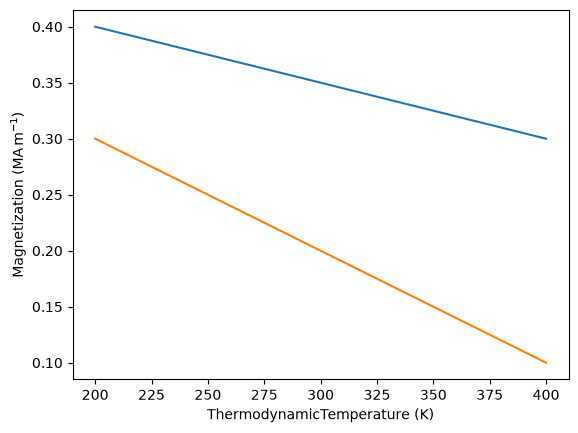

In [4]:
plt.plot(ec.T, ec.M2)
plt.plot(ec.T, ec.M)

## Conversion errors

ConversionError: Failed to convert value(s) to axis units: array([Entity(ontology_label='MagneticFluxDensity', value=array([250., 250., 250.]), unit='mT')],
      dtype=object)

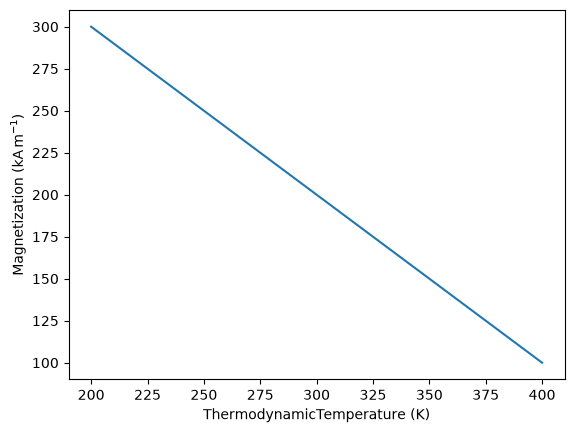

In [5]:
# UnitConversionError
plt.plot(ec.T, ec.M)
plt.plot(ec.T, ec.B)

## Using equivalencies

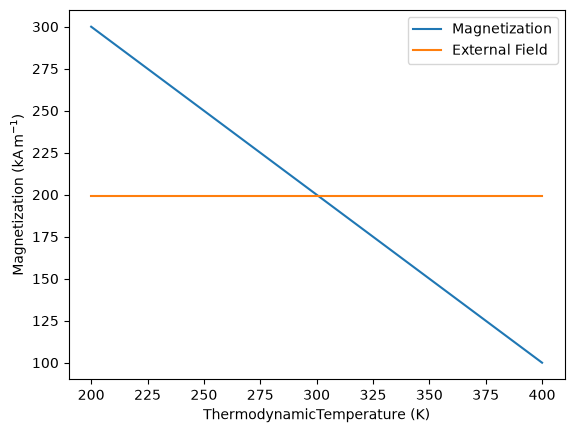

In [6]:
with u.set_enabled_equivalencies(u.magnetic_flux_field()):
    plt.plot(ec.T, ec.M, label="Magnetization")
    plt.plot(ec.T, ec.B, label="External Field")
    plt.legend()

## Quantities

Not possible to plot `Entity`-`Quantity`

ValueError: x and y must have same first dimension, but have shapes (1,) and (3,)

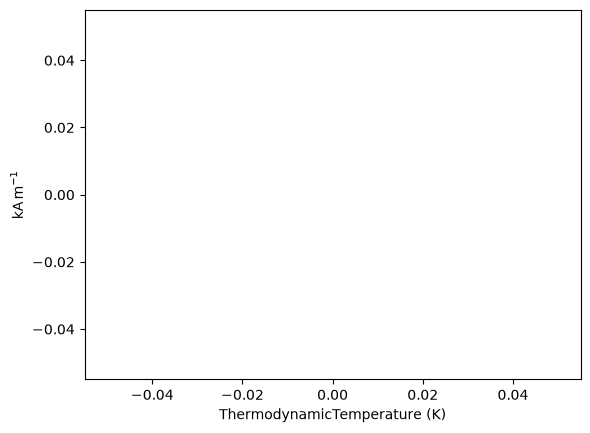

In [7]:
plt.plot(ec.T, ec.M3)

Need to have two quantities (units activated via the `astropy.visualization.quantity_support`):

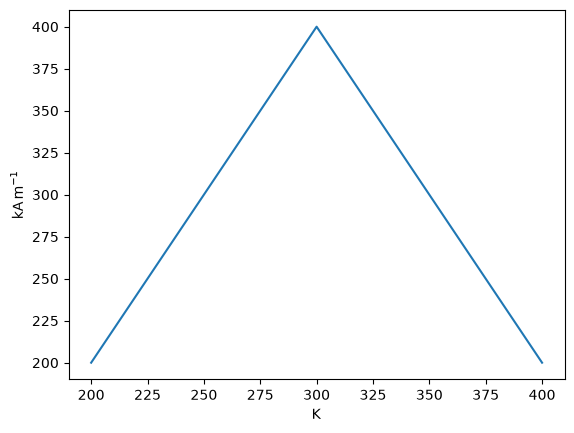

In [8]:
plt.plot(ec.T.q, ec.M3)

Not possible to plot a `Entity`-`Entity` and a `Quantity`-`Quantity` together.

/tmp/ipykernel_3398226/326769707.py:2: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(ec.T.q, ec.M3)


AttributeError: 'tuple' object has no attribute 'to_string'

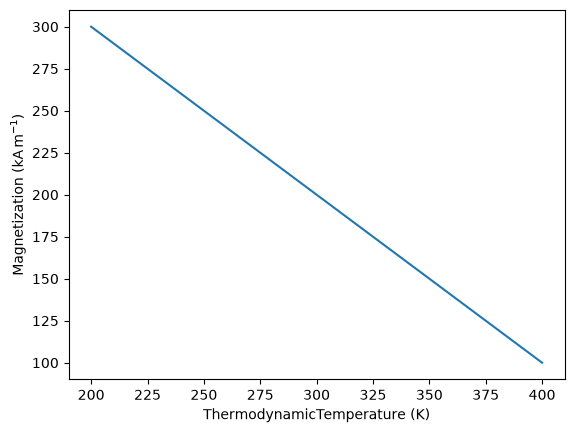

In [9]:
plt.plot(ec.T, ec.M)
plt.plot(ec.T.q, ec.M3)

But we can plot `Entity`-`Entity` and `Array`-`Array` together:

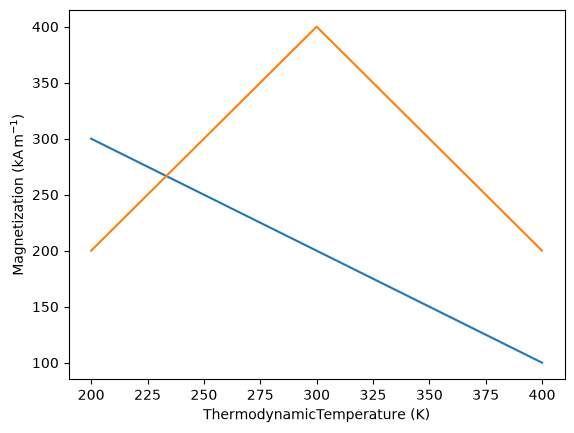

In [10]:
plt.plot(ec.T, ec.M)
plt.plot(ec.T.value, ec.M3.value)